In [ ]:
!pip install pandas scikit-learn numpy

# New section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the dataset.

Preprocess features (logFC, AveExpr, t, P.Value, adj.P.Val, B).

Define a target label (e.g., significant based on adj.P.Val < 0.05).

Train.

Evaluate the model.

Random Forest Regressor Results (Target = logFC )
MSE: 0.05860225466955253
R2 Score: 0.842659364854365

Linear Regression Results (Target = logFC )
MSE: 0.10394419999886864
R2 Score: 0.720921207899802


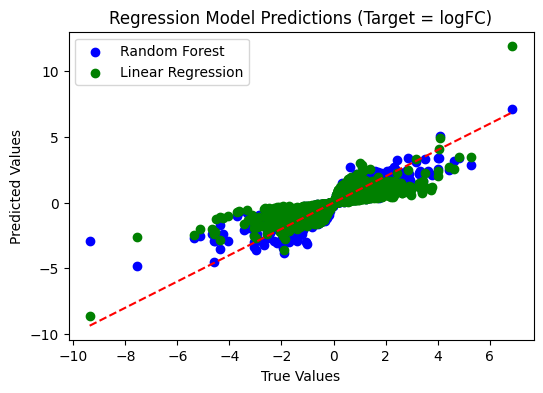

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- Step 1: Load data ---
data = pd.read_csv("/content/DEG_GEO ids.csv")  # Save your data in CSV first

# === Step 2: Choose Target Variable ===
# Options: "logFC" or "B"
target = "logFC"   # <-- change to "B" if you want to predict B instead

X = data[['AveExpr', 't', 'P.Value', 'adj.P.Val']]
y = data[target]

# === Step 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Step 4A: Random Forest Regressor ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Regressor Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

# === Step 4B: Linear Regression (for comparison) ===
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLinear Regression Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

# === Step 5: Visualization ===
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, label="Random Forest", color="blue")
plt.scatter(y_test, y_pred_lr, label="Linear Regression", color="green")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # y=x line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions (Target = {target})")
plt.legend()
plt.show()


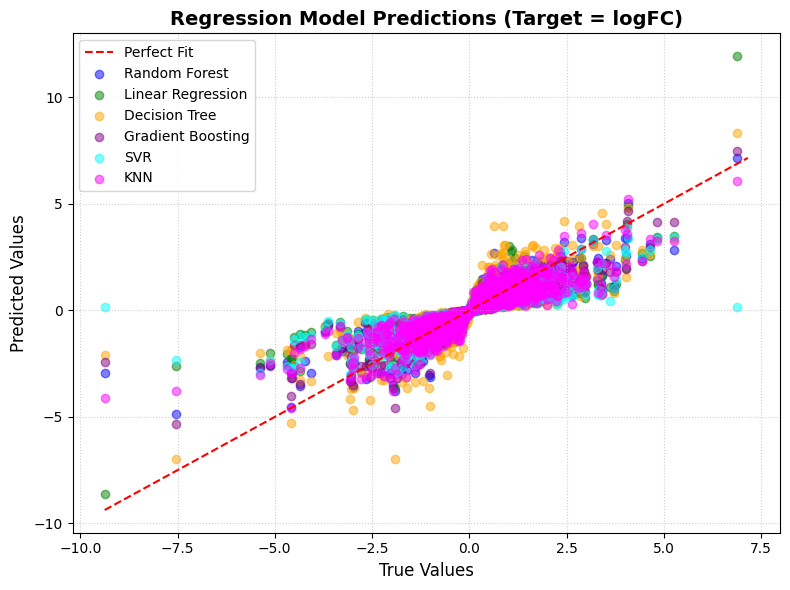

In [ ]:
# --- Step 3: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Step 4: Train All Models ---
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# 1. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 2. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 3. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 4. Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# 5. Support Vector Regressor (SVR)
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# 6. KNN Regressor
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)


# --- Step 5: Visualization ---
plt.figure(figsize=(8, 6))

# Perfect alignment reference line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

# Add all scatter layers
plt.scatter(y_test, y_pred_rf, label="Random Forest", color="blue", alpha=0.5)
plt.scatter(y_test, y_pred_lr, label="Linear Regression", color="green", alpha=0.5)
plt.scatter(y_test, y_pred_dt, label="Decision Tree", color="orange", alpha=0.5)
plt.scatter(y_test, y_pred_gb, label="Gradient Boosting", color="purple", alpha=0.5)
plt.scatter(y_test, y_pred_svr, label="SVR", color="cyan", alpha=0.5)
plt.scatter(y_test, y_pred_knn, label="KNN", color="magenta", alpha=0.5)

# Formatting
plt.title('Regression Model Predictions (Target = logFC)', fontsize=14, fontweight='bold')
plt.xlabel('True Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# 1. Update this with the exact column name you found in Step 1
gene_column_name = 'Gene_Symbol'

# 2. Make sure we remove any missing/blank values in that column
clean_data = data.dropna(subset=[gene_column_name])

# 3. Predict and sort by absolute predicted logFC
clean_data['Predicted_logFC'] = rf.predict(X.loc[clean_data.index])
clean_data['Abs_Predicted_logFC'] = clean_data['Predicted_logFC'].abs()

# 4. Extract the true top 50 gene names
top_50_df = clean_data.sort_values(by='Abs_Predicted_logFC', ascending=False).head(50)
top_50_genes = top_50_df[gene_column_name].tolist()

print("--- CORRECTED TOP 50 GENES ---")
print(top_50_genes)


--- CORRECTED TOP 50 GENES ---
['ahpC///ahpC///ahpC///ECs0644', 'ahpF///ahpF///ahpF///ECs0645', 'katG///katG///katG///ECs4871', 'c0693', 'cspI', 'fliC', 'ynfN', 'b4400', 'b1110', 'b3716', 'tar///tar///tar///ECs2596', 'motB///motB///motB///motB', 'b0379', 'katE///katE///katE///katE', 'b4431', 'ydfK', 'c2589', 'c0547', 'b1951', 'cheA///cheA///cheA///ECs2598', 'b3690', 'cysJ///cysJ///cysJ///cysJ', 'oxyS///oxyS', 'cheY///cheY///cheY///ECs2592', 'c1618', 'c2930', 'isrC', 'yiiL', 'cspH', 'fliD///fliD', 'cheB///cheB///cheB///ECs2593', 'yeeE///yeeE///ECs2815', 'ycgX', 'ycgR///ycgR', 'grxA///grxA///grxA///grxA', 'flu', 'ECs2085', 'flxA', 'b3717', 'hemH///hemH///hemH///hemH', 'ybcS', 'cspB', 'b2671', 'ycgK', 'c5447///ECs5328', 'cpxP', 'motA///motA///motA///ECs2600', 'tap///tap///ECs2595', 'cheR///cheR///cheR///ECs2594', 'yhjH///yhjH///yhjH///ECs4405']


In [ ]:
import re

cleaned_genes = []

for item in top_50_genes:
    if pd.isna(item):
        continue
    # Split the string by any occurrences of slashes (/, //, ///)
    split_names = re.split(r'/+', str(item))

    for name in split_names:
        clean_name = name.strip()
        # Keep it if it is a valid name and not already added
        if clean_name and clean_name not in cleaned_genes:
            cleaned_genes.append(clean_name)

# Ensure we keep a strong subset (let's print the unique list)
print("--- CLEANED GENES FOR STRING-DB ---")
print(cleaned_genes)


--- CLEANED GENES FOR STRING-DB ---
['ahpC', 'ECs0644', 'ahpF', 'ECs0645', 'katG', 'ECs4871', 'c0693', 'cspI', 'fliC', 'ynfN', 'b4400', 'b1110', 'b3716', 'tar', 'ECs2596', 'motB', 'b0379', 'katE', 'b4431', 'ydfK', 'c2589', 'c0547', 'b1951', 'cheA', 'ECs2598', 'b3690', 'cysJ', 'oxyS', 'cheY', 'ECs2592', 'c1618', 'c2930', 'isrC', 'yiiL', 'cspH', 'fliD', 'cheB', 'ECs2593', 'yeeE', 'ECs2815', 'ycgX', 'ycgR', 'grxA', 'flu', 'ECs2085', 'flxA', 'b3717', 'hemH', 'ybcS', 'cspB', 'b2671', 'ycgK', 'c5447', 'ECs5328', 'cpxP', 'motA', 'ECs2600', 'tap', 'ECs2595', 'cheR', 'ECs2594', 'yhjH', 'ECs4405']


In [ ]:
print(data.columns.tolist())


['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'Gene_Symbol']


Linear Regression → MSE: 0.1039, R²: 0.7209
Random Forest → MSE: 0.0586, R²: 0.8427
Decision Tree → MSE: 0.0931, R²: 0.7500
Gradient Boosting → MSE: 0.0646, R²: 0.8266
Support Vector Regressor → MSE: 0.0871, R²: 0.7661
KNN Regressor → MSE: 0.0685, R²: 0.8161


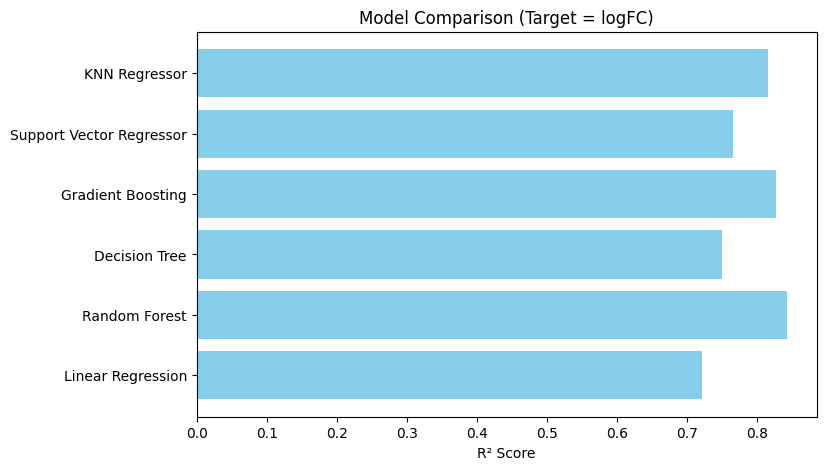

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor



# === Step 6: Define Models ===
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=3)
}

results = {}

# === Step 7: Train and Evaluate Each Model ===
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} → MSE: {mse:.4f}, R²: {r2:.4f}")

# === Step 8: Visualization of R² scores ===
plt.figure(figsize=(8,5))
r2_scores = [results[m]["R2"] for m in results]
plt.barh(list(results.keys()), r2_scores, color="skyblue")
plt.xlabel("R² Score")
plt.title(f"Model Comparison (Target = {target})")
plt.show()
